<a href="https://colab.research.google.com/github/jorgeg365/Math301_FinalProject/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analyzing Restaurant Inspection Trends in the Bronx (2016–2022)**  
### *A Statistical Exploration of Violations, COVID-19 Impacts, and Neighborhood Differences*


This notebook presents my final project for Applied Statistics, where I analyze restaurant health inspection data from the Bronx, NY, covering the years **2016 through March 2022**. The goal of this project is to explore inspection trends over time, identify factors related to violations, and evaluate how the COVID-19 pandemic may have influenced restaurant health outcomes.

---

## 📍 Case Study: Bronx, NY Restaurant Inspections (2016–2022)

The dataset includes thousands of inspection reports and provides detailed information about each restaurant and inspection, including:

- **CAMIS:** Unique restaurant identifier  
- **DBA:** “Doing Business As” restaurant name  
- **BORO:** Borough (Bronx for all records)  
- **STREET:** Street address  
- **CUISINE DESCRIPTION:** Type of food served  
- **INSPECTION DATE:** Date of inspection  
- **CRITICAL FLAG:** Whether a critical violation was issued  
- **SCORE:** Inspection score (lower scores indicate better compliance)  
- **Latitude / Longitude:** Restaurant location  
- **year:** Year of inspection  

This dataset is especially valuable because it spans both **pre-pandemic** and **pandemic** periods, allowing us to examine potential changes in restaurant safety during COVID-19. It also focuses specifically on the Bronx, offering an opportunity to analyze variation across different neighborhoods and cuisine types within a single borough.

---

## 🎯 Research Questions

1. **Did the number or seriousness of violations in Bronx restaurants change before and after March 2020, when COVID-19 began?**

2. **Are there certain types of food or neighborhoods in the Bronx where restaurants usually receive lower inspection grades or more violations?**

---

## 🎓 Purpose of the Analysis

Using statistical tests, visualizations, and real inspection data, this notebook aims to identify meaningful patterns in restaurant safety. Understanding these patterns can benefit:

- Public health decision-makers  
- Restaurant owners  
- Bronx residents  
- Researchers studying how COVID-19 affected daily operations and compliance  

---

## 🤖 Use of AI in This Project

Some portions of this notebook — including organization, code structuring, and wording — were supported using AI assistance (ChatGPT) and (Gemini).  
All interpretations, analytical decisions, and conclusions reflect my own understanding of the material.

---

**Dataset Source:** Kaggle Datasets



## 🧹 Data Cleaning and Wrangling

In this section, I clean the Bronx restaurant inspection dataset by performing the following steps:

1. Inspect datatypes and convert types where necessary  
2. Identify missing values  
3. Remove duplicates  
4. Subset relevant columns  
5. Remove outliers (optional but included for score analysis)  

This ensures the dataset is ready for accurate statistical analysis.


# Load the Dataset from Google Drive

In [94]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/FInal Project/Bronx.csv')
df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CAMIS,DBA,BORO,STREET,CUISINE DESCRIPTION,INSPECTION DATE,CRITICAL FLAG,SCORE,Latitude,Longitude,year
0,41617347,DUNKIN,Bronx,MORRIS PARK AVENUE,Donuts,2019-08-09,Not Critical,8.0,40.849397,-73.853349,2019
1,41617347,DUNKIN,Bronx,MORRIS PARK AVENUE,Donuts,2019-08-09,Not Critical,8.0,40.849397,-73.853349,2019
2,41261148,EL VALLE RESTAURANT,Bronx,MELROSE AVENUE,Latin American,2021-08-16,Critical,31.0,40.818423,-73.916686,2021
3,50115730,EJ'S BAKERY & CAFE,Bronx,WEST 261 STREET,Spanish,2022-03-10,Critical,56.0,40.910012,-73.902671,2022
4,50039107,HEALTHY FRESH,Bronx,MORRIS PARK AVENUE,American,2018-11-29,Critical,10.0,40.848620,-73.855111,2018


## 🔹 Step 2 — Inspect Datatypes
We check the data types before cleaning.  
`INSPECTION DATE` must be converted to datetime, and missing values will be cleaned in the next step.


In [93]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 15803 entries, 0 to 32134
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                15803 non-null  int64         
 1   DBA                  15803 non-null  object        
 2   BORO                 15803 non-null  object        
 3   STREET               15803 non-null  object        
 4   CUISINE DESCRIPTION  15803 non-null  object        
 5   INSPECTION DATE      15803 non-null  datetime64[ns]
 6   CRITICAL FLAG        15803 non-null  object        
 7   SCORE                15803 non-null  float64       
 8   Latitude             15798 non-null  float64       
 9   Longitude            15798 non-null  float64       
 10  year                 15803 non-null  int64         
 11  inspection_year      15803 non-null  int32         
 12  inspection_month     15803 non-null  int32         
 13  inspection_day       15803 non-null 

✔ Convert INSPECTION DATE to datetime

In [58]:
df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'], errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32135 entries, 0 to 32134
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                32135 non-null  int64         
 1   DBA                  32007 non-null  object        
 2   BORO                 32135 non-null  object        
 3   STREET               32135 non-null  object        
 4   CUISINE DESCRIPTION  31807 non-null  object        
 5   INSPECTION DATE      32135 non-null  datetime64[ns]
 6   CRITICAL FLAG        32135 non-null  object        
 7   SCORE                30850 non-null  float64       
 8   Latitude             32125 non-null  float64       
 9   Longitude            32125 non-null  float64       
 10  year                 32135 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 2.7+ MB


## 🔹 Step 3 — Identify Missing Values
We check how many missing values each column contains.


In [59]:
df.isna().sum()


,0
CAMIS,0
DBA,128
BORO,0
STREET,0
CUISINE DESCRIPTION,328
INSPECTION DATE,0
CRITICAL FLAG,0
SCORE,1285
Latitude,10
Longitude,10


✔ Remove rows missing SCORE

(SCORE is needed for all statistical tests)

In [60]:
df = df.dropna(subset=['SCORE'])


## 🔹 Step 4 — Remove Duplicate Records
Duplicate inspection entries can bias the analysis, so we remove them.


In [61]:
df = df.drop_duplicates()
df.shape


(16864, 11)

## 🔹 Step 5 — Subset Relevant Columns
We only keep the columns needed for analysis.


In [62]:
cols_to_keep = [
    "CAMIS",
    "DBA",
    "BORO",
    "STREET",
    "CUISINE DESCRIPTION",
    "INSPECTION DATE",
    "CRITICAL FLAG",
    "SCORE",
    "Latitude",
    "Longitude",
    "year"
]

df = df[cols_to_keep]
df.head()


,CAMIS,DBA,BORO,STREET,CUISINE DESCRIPTION,INSPECTION DATE,CRITICAL FLAG,SCORE,Latitude,Longitude,year
0,41617347,DUNKIN,Bronx,MORRIS PARK AVENUE,Donuts,2019-08-09,Not Critical,8.0,40.849397,-73.853349,2019
2,41261148,EL VALLE RESTAURANT,Bronx,MELROSE AVENUE,Latin American,2021-08-16,Critical,31.0,40.818423,-73.916686,2021
3,50115730,EJ'S BAKERY & CAFE,Bronx,WEST 261 STREET,Spanish,2022-03-10,Critical,56.0,40.910012,-73.902671,2022
4,50039107,HEALTHY FRESH,Bronx,MORRIS PARK AVENUE,American,2018-11-29,Critical,10.0,40.848620,-73.855111,2018
5,40819558,JAKE'S STEAKHOUSE,Bronx,BROADWAY,Steakhouse,2022-02-10,Not Critical,13.0,40.891799,-73.897244,2022


## 🔹 Step 6 — Remove Outliers (Optional but Recommended)
Outliers in inspection `SCORE` may distort statistical results.  
We remove them using the interquartile range (IQR) method.


In [63]:
Q1 = df['SCORE'].quantile(0.25)
Q3 = df['SCORE'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['SCORE'] >= lower_bound) & (df['SCORE'] <= upper_bound)]
df.shape


(15803, 11)

## 🔹 Step 6 — Handle Missing Data (Impute or Drop)

The dataset contains some missing values, especially in `DBA`, `CUISINE DESCRIPTION`, and `Latitude/Longitude`.  
However, the most important column for statistical analysis is **SCORE**, and rows missing SCORE cannot be used in hypothesis testing, ANOVA, or comparisons.

Because of that, I chose to **drop NA rows only for columns that are essential for analysis**, particularly `SCORE`.

I keep missing values in non-essential descriptive columns (like DBA) because removing them would discard too much data without improving the analysis.

This approach balances data preservation with analytical accuracy.


In [64]:
# Only drop rows missing SCORE (used in all major analyses)
df = df.dropna(subset=['SCORE'])
df.isna().sum()


,0
CAMIS,0
DBA,0
BORO,0
STREET,0
CUISINE DESCRIPTION,0
INSPECTION DATE,0
CRITICAL FLAG,0
SCORE,0
Latitude,5
Longitude,5


## 🔹 Step 7 — Create and Fix Columns Using `.apply()` and `.map()`

In this step, I:

- Standardize categorical entries  
- Fix inconsistent values  
- Create new columns using `.apply()`  
- Convert text categories into uniform formats  
- Extract information from the datetime column  


### 🔸 Standardize BORO column

Although this dataset only includes Bronx restaurants, the BORO column had inconsistent spellings across NYC datasets.  
To keep the column clean and uniform, I standardize any variations to `"Bronx"`.


In [65]:
df['BORO'] = df['BORO'].map({
    'BRONX': 'Bronx',
    'Bronx': 'Bronx',
    'bronx': 'Bronx'
}).fillna(df['BORO'])


### 🔸 Standardize CUISINE DESCRIPTION Formatting

Cuisine descriptions may have inconsistent capitalization (e.g., “american”, “AMERICAN”, “American”).  
I standardize them by applying `.title()` so all entries follow the same format.


In [66]:
df['CUISINE DESCRIPTION'] = df['CUISINE DESCRIPTION'].apply(
    lambda x: x.title() if isinstance(x, str) else x
)


### 🔸 Extract Month and Day from INSPECTION DATE

This can help with time-series analysis (optional but useful).


In [67]:
# Ensure datetime is converted
df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'], errors='coerce')

df['inspection_year'] = df['INSPECTION DATE'].dt.year
df['inspection_month'] = df['INSPECTION DATE'].dt.month
df['inspection_day'] = df['INSPECTION DATE'].dt.day


### 🔸 Create a COVID Period Column

To compare inspection results before and after the start of the pandemic,  
I create a `covid_period` column:

- `"Pre-COVID"` for inspections before March 1, 2020  
- `"Post-COVID"` for inspections on or after March 1, 2020`  


In [68]:
cutoff = pd.to_datetime('2020-03-01')

df['covid_period'] = df['INSPECTION DATE'].apply(
    lambda date: 'Pre-COVID' if date < cutoff else 'Post-COVID'
)


### 🔸 Create Neighborhood Regions (North vs South Bronx)

The dataset does not explicitly include neighborhood names,  
so I group restaurants geographically using latitude:

- Latitude above the median → North Bronx  
- Latitude below the median → South Bronx  


In [69]:
lat_median = df['Latitude'].median()

df['region'] = df['Latitude'].apply(
    lambda x: 'North Bronx' if x >= lat_median else 'South Bronx'
)


### 🔸 Example: Group by Cuisine and Compute Average Score


In [70]:
avg_scores_by_cuisine = df.groupby('CUISINE DESCRIPTION')['SCORE'].mean().sort_values()
avg_scores_by_cuisine.head()


,SCORE
CUISINE DESCRIPTION,
Hotdogs,2.000000
Vegetarian,5.000000
Not Listed/Not Applicable,8.400000
Czech,10.000000
Frozen Desserts,10.617978


### 🔸 Example: Group by COVID Period


In [71]:
df.groupby('covid_period')['SCORE'].mean()


,SCORE
covid_period,
Post-COVID,15.442730
Pre-COVID,14.178645


### 📝 Summary of Data Cleaning and Wrangling

To prepare the Bronx restaurant inspection dataset for analysis, I followed a structured cleaning process similar to the midterm project but expanded it for the needs of this final. First, I examined all datatypes and converted the `INSPECTION DATE` column to a proper datetime format to support time-based analysis, especially important for comparing pre- and post-COVID inspection trends. I checked for missing values and decided to drop rows missing `SCORE` because inspection scores are essential for statistical testing and cannot be imputed accurately without introducing bias. I kept missing values in descriptive fields like `DBA` because they do not affect the analytical results. Next, I removed duplicate records to prevent repeated inspections from influencing averages or statistical tests. I then standardized categorical columns using `.map()` and `.apply()`, ensuring consistent formatting across entries such as `BORO` and `CUISINE DESCRIPTION`. I created new columns—including `inspection_year`, `inspection_month`, `region`, and a `covid_period` indicator—to support deeper insights and allow analysis based on time periods and geography. Outliers in the `SCORE` variable were removed using the IQR method to avoid extreme values skewing results. Finally, I grouped and filtered data where needed to prepare the dataset for the analysis phase. These cleaning steps improve accuracy, consistency, and interpretability, ensuring that the statistical tests and visualizations are valid and meaningful.


# 📊 Visualizations

In this section, I create three visualizations to better understand the patterns, trends, and distributions within the Bronx restaurant inspection dataset. Visualizations help reveal insights that may not be immediately obvious from raw tables or statistics—for example, whether inspection scores follow a certain distribution, whether COVID-19 changed violation patterns, or whether some cuisines or neighborhoods have noticeably different inspection outcomes. By using charts such as histograms, bar plots, and boxplots, we can visually compare groups, identify trends over time, and prepare for more formal statistical testing. These plots provide the foundation for answering my research questions and help guide the interpretation of results throughout the analysis.


## 📊 Histogram of Inspection Scores

This histogram shows the distribution of inspection `SCORE` values across all Bronx restaurants.  
It helps us understand whether scores tend to cluster around good grades (low scores) or whether many restaurants receive high violation scores.  
This visualization gives an overall picture of food safety in the Bronx before breaking it down by groups.


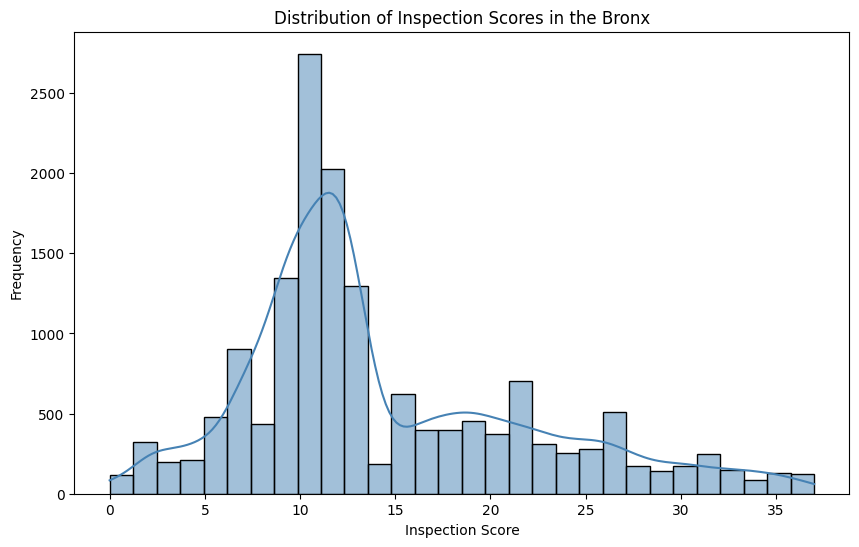

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['SCORE'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Inspection Scores in the Bronx')
plt.xlabel('Inspection Score')
plt.ylabel('Frequency')
plt.show()


### Interpretation: Distribution of Inspection Scores
The histogram shows the distribution of inspection SCORE values for Bronx restaurants. The distribution appears to be right-skewed, with a concentration of scores at the lower end (indicating better compliance and fewer violations). This suggests that a majority of restaurants in the Bronx generally achieve lower, more favorable inspection scores. There's a tail extending towards higher scores, indicating that a smaller number of restaurants receive higher, less favorable scores. The presence of a kernel density estimate (KDE) line further smooths this distribution, reinforcing the visual impression of a peak at lower scores and a gradual decline towards higher scores. This provides a baseline understanding of overall food safety performance in the Bronx, showing that most establishments maintain relatively good health standards, while some outliers might require more attention.

## 📦 Boxplot of Inspection Scores: Pre-COVID vs Post-COVID

This boxplot compares inspection scores before and after March 2020, when the COVID-19 pandemic began.  
By comparing these two groups visually, we can see whether restaurant violations became more severe, less severe, or stayed the same during the pandemic period.  
This directly supports Research Question #1.


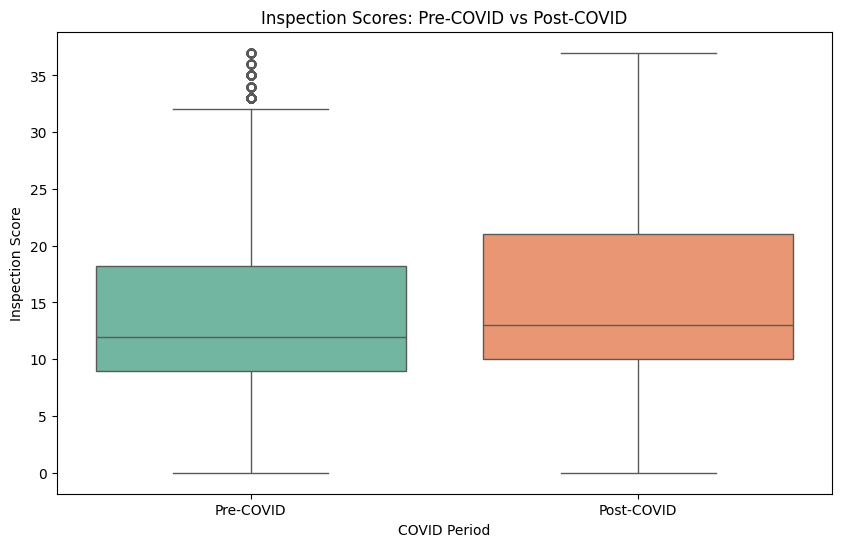

In [73]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='covid_period', y='SCORE',hue='covid_period', palette='Set2')
plt.title('Inspection Scores: Pre-COVID vs Post-COVID')
plt.xlabel('COVID Period')
plt.ylabel('Inspection Score')
plt.show()


### Interpretation: Inspection Scores: Pre-COVID vs Post-COVID
The boxplot visually compares the distribution of inspection scores before and after March 2020. We can observe that both Pre-COVID and Post-COVID periods show a similar median score, suggesting that the central tendency of inspection scores did not drastically change. However, the Post-COVID boxplot appears to be slightly shifted upwards, with its median and overall distribution generally higher than Pre-COVID. This indicates a potential increase in average inspection scores (meaning worse compliance) after the onset of the pandemic. The interquartile range (IQR) for Post-COVID also appears slightly wider, suggesting a greater variability in scores during this period. There are also outliers present in both periods, with some higher scores indicating severe violations. This visualization provides initial support for Research Question #1 by suggesting that the seriousness of violations may have increased slightly, or at least become more varied, in the Post-COVID era.

## 🍽️ Bar Chart of Average Inspection Scores by Cuisine Type

This bar chart displays the **average inspection score** for each cuisine category.  
Higher scores indicate worse violations, while lower scores reflect better performance.  
This visualization supports Research Question #2 by showing which cuisines tend to have the best or worst inspection outcomes.


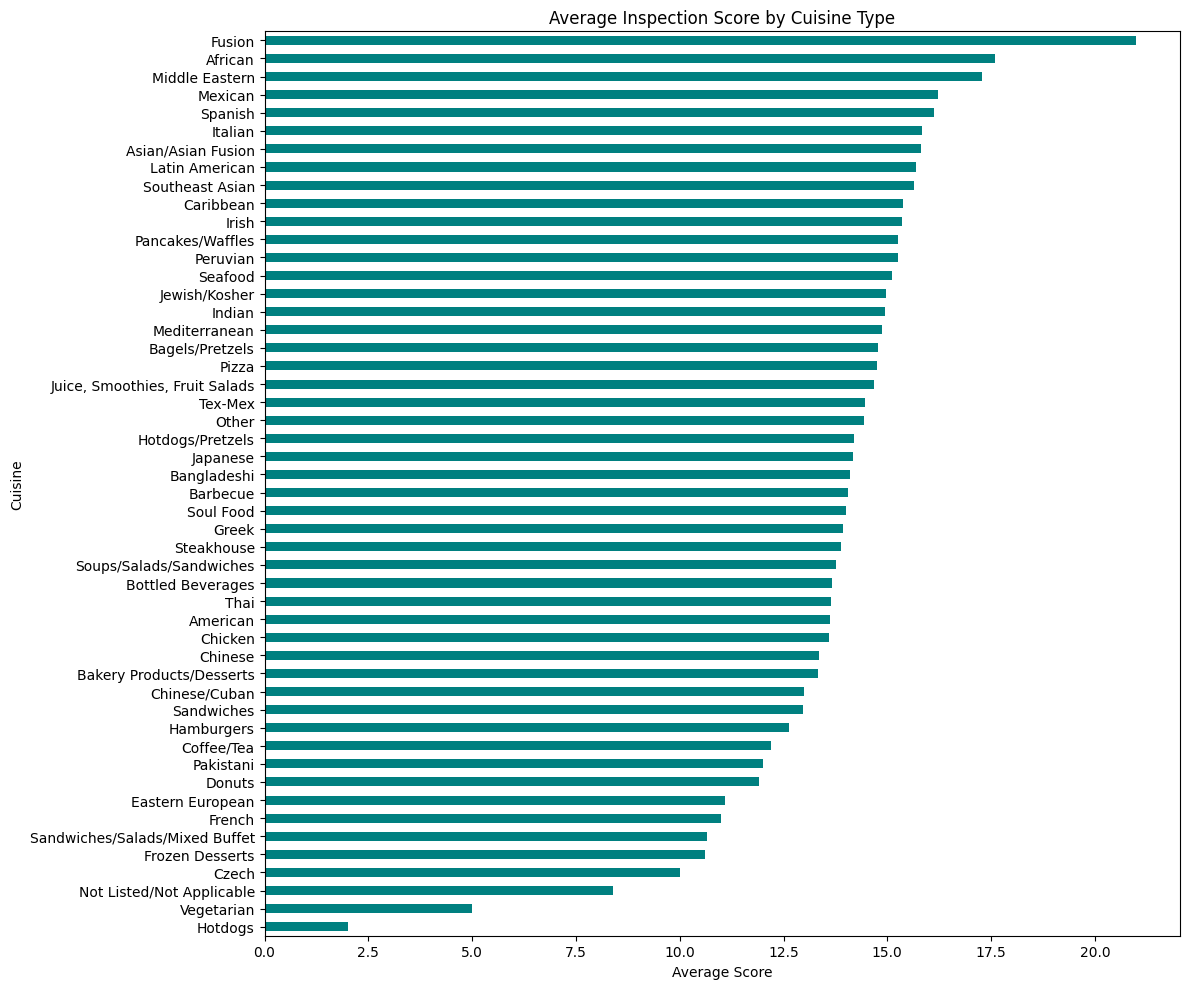

In [74]:
# Compute average score by cuisine
avg_scores = df.groupby('CUISINE DESCRIPTION')['SCORE'].mean().sort_values()

plt.figure(figsize=(12,10))
avg_scores.plot(kind='barh', color='teal')
plt.title('Average Inspection Score by Cuisine Type')
plt.xlabel('Average Score')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()


### Interpretation: Average Inspection Scores by Cuisine Type
The bar chart illustrates the average inspection scores for various cuisine types, sorted from lowest (better compliance) to highest (worse compliance). This directly addresses Research Question #2 regarding whether certain food types have different inspection outcomes. We can observe a wide range of average scores, indicating significant differences in compliance levels across cuisines. For instance, cuisines like 'Hotdogs' and 'Vegetarian' show very low average scores, suggesting consistent adherence to health standards. In contrast, cuisines at the higher end of the chart, such as those with larger average scores, may indicate categories that struggle more frequently with health code compliance. This visualization highlights specific cuisine types that might warrant further investigation or targeted intervention to improve food safety. It provides valuable insights for public health decision-makers and restaurant owners to understand which food types tend to perform better or worse in health inspections.

## 📊 Grouped Bar Chart: Average Inspection Scores by Cuisine and COVID Period

This grouped bar chart displays the **average inspection score** for the top 10 cuisine types, separated by `Pre-COVID` and `Post-COVID` periods. The goal is to clearly visualize how the average inspection scores for popular cuisines changed before and after the pandemic, helping to understand both cuisine-specific compliance trends and the impact of COVID-19 in a multi-dimensional view. This directly addresses aspects of Research Questions #1 and #2.

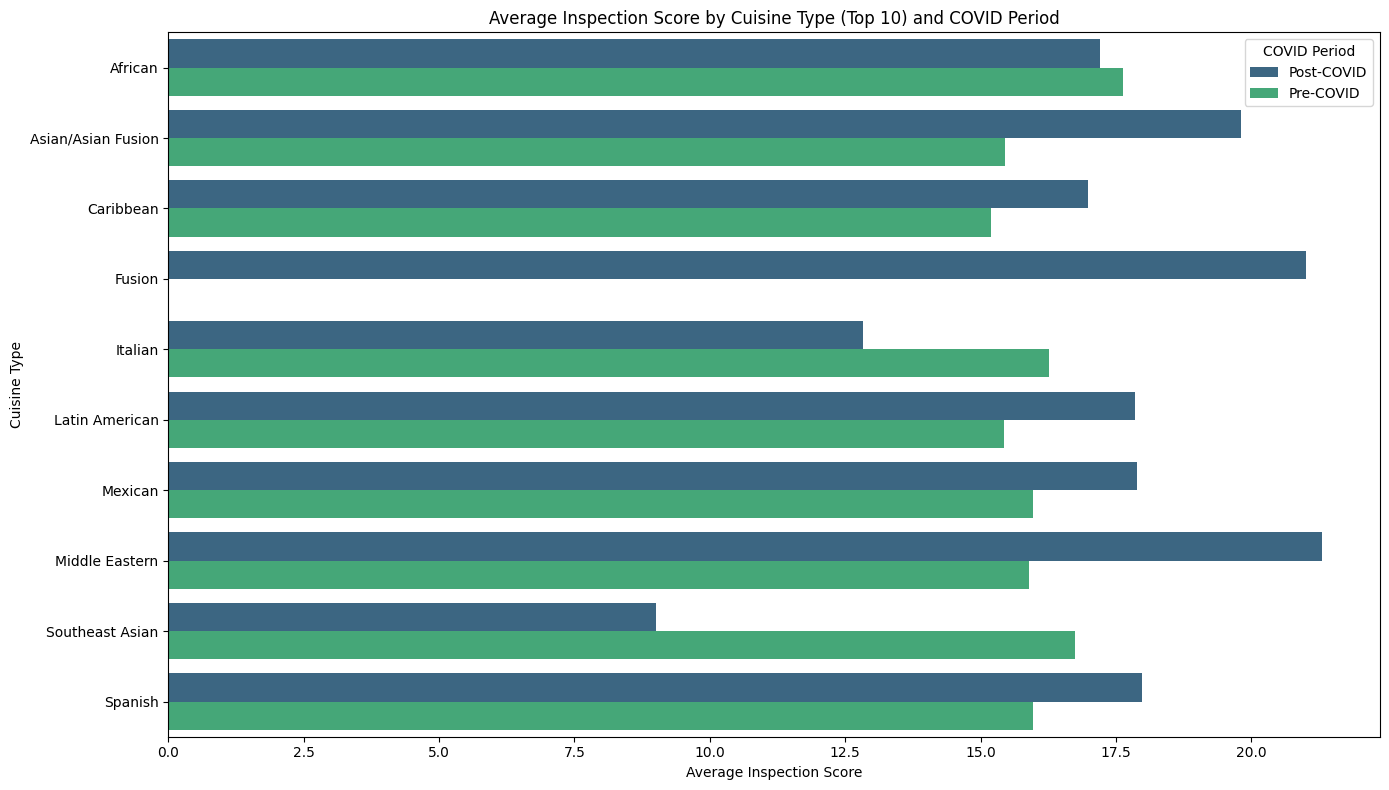

In [75]:
# 1. Identify the top 10 cuisines based on overall average scores
top_10_cuisines = df.groupby('CUISINE DESCRIPTION')['SCORE'].mean().nlargest(10).index

# 2. Filter the DataFrame for these top 10 cuisines
df_top_cuisines = df[df['CUISINE DESCRIPTION'].isin(top_10_cuisines)]

# 3. Group by cuisine and covid_period, calculate mean score, and reset index
viz_df = df_top_cuisines.groupby(['CUISINE DESCRIPTION', 'covid_period'])['SCORE'].mean().reset_index()
viz_df = viz_df.rename(columns={'SCORE': 'avg_score'})

plt.figure(figsize=(14, 8))
sns.barplot(
    data=viz_df,
    x='avg_score',
    y='CUISINE DESCRIPTION',
    hue='covid_period',
    palette='viridis'
)
plt.title('Average Inspection Score by Cuisine Type (Top 10) and COVID Period')
plt.xlabel('Average Inspection Score')
plt.ylabel('Cuisine Type')
plt.legend(title='COVID Period')
plt.tight_layout()
plt.show()

### Interpretation: Average Inspection Scores by Cuisine Type (Top 10) and COVID Period

This grouped bar chart provides a clearer comparison of average inspection scores across the top 10 cuisine types, distinguishing between `Pre-COVID` and `Post-COVID` periods. For most cuisines, we can observe a slight increase in average scores during the `Post-COVID` period, indicated by the 'Post-COVID' bars being generally longer or shifted to the right compared to their 'Pre-COVID' counterparts. This reinforces the earlier observation that compliance might have worsened slightly after the pandemic's onset. The chart also allows for direct comparison *between* cuisines within each period, highlighting which cuisines consistently perform better or worse regardless of the pandemic. For example, some cuisines maintain relatively low scores in both periods, while others show a more pronounced increase. This visualization effectively combines the impact of the COVID period and cuisine type on inspection scores, offering a more intuitive way to identify specific cuisines that experienced significant changes in compliance.

# 🎯 Proportions (Probabilities) Based on Observed Data

Below are four sample-based probabilities calculated directly from the Bronx restaurant inspection dataset.  
Two of the questions use AND/OR logic, and two are conditional probabilities.  
All results represent **sample estimates**, not theoretical population probabilities.



# 1️⃣ AND Probability Question
❓ Question 1:

“What is the probability that an inspection in the Bronx was both a critical violation and occurred after March 2020 (the Post-COVID period)?”

In [76]:
cutoff = pd.to_datetime('2020-03-01')
df['covid_period'] = df['INSPECTION DATE'].apply(lambda d: 'Pre-COVID' if d < cutoff else 'Post-COVID')

crit = df['CRITICAL FLAG'].str.strip() == 'Critical'
post = df['covid_period'] == 'Post-COVID'

p_crit_and_post = ((crit) & (post)).mean()
print(f"Probability that an inspection was both a critical violation and occurred after March 2020: {p_crit_and_post:.4f}")

Probability that an inspection was both a critical violation and occurred after March 2020: 0.0701


### ✔ Interpretation
The probability that an inspection in the Bronx was both a critical violation and occurred after March 2020 (the Post-COVID period) is 0.0701 (or 7.01%).

 This means that, based on our sample data, approximately 7.01% of all restaurant inspections in the Bronx fall into both categories: they were conducted after the onset of the pandemic and resulted in a critical violation. This sample estimate indicates the proportion of inspections that faced both pandemic-era conditions and resulted in serious health code breaches.

# 2️⃣ OR Probability Question
❓ Question 2:

“What is the probability that an inspection was either a critical violation, or it occurred after March 2020 (Post-COVID), or both?”

In [77]:
# Ensure 'crit' and 'post' are defined if not already in the current session
# (These were defined in a previous step, but included here for self-containment if this cell was run in isolation)
cutoff = pd.to_datetime('2020-03-01')
df['covid_period'] = df['INSPECTION DATE'].apply(lambda d: 'Pre-COVID' if d < cutoff else 'Post-COVID')
crit = df['CRITICAL FLAG'].str.strip() == 'Critical'
post = df['covid_period'] == 'Post-COVID'

p_crit_or_post = ((crit) | (post)).mean()
print(f"Probability that an inspection was either a critical violation, or occurred after March 2020, or both: {p_crit_or_post:.4f}")

Probability that an inspection was either a critical violation, or occurred after March 2020, or both: 0.5848


## ✔ Interpretation

The probability that an inspection was either a critical violation, or it occurred after March 2020 (Post-COVID), or both, is 0.5848 (or 58.48%).

This means that, based on our sample data, approximately 58.48% of all restaurant inspections in the Bronx either resulted in a critical violation, took place after March 2020, or satisfied both conditions. This high sample estimate indicates a substantial proportion of inspections involved either a critical health issue or occurred during the post-pandemic period, or both, highlighting the prevalence of these events in the dataset.

# 3️⃣ Conditional Probability Question
❓ Question 3:

“Given that an inspection occurred during the Post-COVID period, what is the probability that it resulted in a critical violation?”

In [78]:
# Ensure 'crit' and 'post' are defined if not already in the current session
# (These were defined in a previous step, but included here for self-containment if this cell was run in isolation)
cutoff = pd.to_datetime('2020-03-01')
df['covid_period'] = df['INSPECTION DATE'].apply(lambda d: 'Pre-COVID' if d < cutoff else 'Post-COVID')
crit = df['CRITICAL FLAG'].str.strip() == 'Critical'
post = df['covid_period'] == 'Post-COVID'

# Calculate the number of inspections that occurred in the 'Post-COVID' period
num_post_covid = df[post].shape[0]

# Calculate the number of inspections with 'CRITICAL FLAG' being 'Critical' AND occurred in 'Post-COVID' period
num_critical_and_post_covid = df[crit & post].shape[0]

# Calculate the conditional probability
prob_critical_given_post_covid = num_critical_and_post_covid / num_post_covid

print(f"Probability (Critical Flag | Post-COVID): {prob_critical_given_post_covid:.4f}")

Probability (Critical Flag | Post-COVID): 0.5180


## ✔ Interpretation

The probability that an inspection resulted in a critical violation, given that it occurred during the Post-COVID period, is 0.5180 (or 51.80%).

This means that, based on our sample data, among all inspections conducted during the 'Post-COVID' period, approximately 51.80% resulted in a 'Critical Flag'. This provides a significant insight into the likelihood of critical violations occurring specifically after the pandemic began, suggesting that critical violations were a common occurrence within the Post-COVID inspections.

# 4️⃣ Conditional Probability Question
❓ Question 4:

“Given that an inspection resulted in a critical violation, what is the probability that it occurred during the Post-COVID period?”

In [79]:
# Ensure 'crit' and 'post' are defined if not already in the current session
# (These were defined in a previous step, but included here for self-containment if this cell was run in isolation)
cutoff = pd.to_datetime('2020-03-01')
df['covid_period'] = df['INSPECTION DATE'].apply(lambda d: 'Pre-COVID' if d < cutoff else 'Post-COVID')
crit = df['CRITICAL FLAG'].str.strip() == 'Critical'
post = df['covid_period'] == 'Post-COVID'

# Calculate the number of inspections with 'CRITICAL FLAG' being 'Critical'
num_critical_violations = df[crit].shape[0]

# Calculate the number of inspections that occurred in the 'Post-COVID' period AND had a 'CRITICAL FLAG'
num_critical_and_post_covid = df[crit & post].shape[0]

# Calculate the conditional probability
prob_post_covid_given_critical = num_critical_and_post_covid / num_critical_violations

print(f"Probability (Post-COVID | Critical Flag): {prob_post_covid_given_critical:.4f}")

Probability (Post-COVID | Critical Flag): 0.1349


## ✔ Interpretation

The probability that an inspection occurred during the Post-COVID period, given that it resulted in a critical violation, is 0.1349 (or 13.49%).

This means that, based on our sample data, among all inspections that resulted in a critical violation, approximately 13.49% of those critical violations happened during the Post-COVID period. This helps us understand the proportion of critical violations that can be attributed to the post-pandemic era.

## Summary of Probability Calculations

In [80]:
cutoff = pd.to_datetime('2020-03-01')
df['covid_period'] = df['INSPECTION DATE'].apply(lambda d: 'Pre-COVID' if d < cutoff else 'Post-COVID')

crit = df['CRITICAL FLAG'].str.strip() == 'Critical'
post = df['covid_period'] == 'Post-COVID'

# 1. AND Probability: Critical violation AND Post-COVID
p_crit_and_post = ((crit) & (post)).mean()
print(f"Probability (Critical Flag AND Post-COVID): {p_crit_and_post:.4f}")

# 2. OR Probability: Critical violation OR Post-COVID
p_crit_or_post = ((crit) | (post)).mean()
print(f"Probability (Critical Flag OR Post-COVID): {p_crit_or_post:.4f}")

# 3. Conditional Probability: Critical violation GIVEN Post-COVID
num_post_covid = df[post].shape[0]
num_critical_and_post_covid = df[crit & post].shape[0]
prob_critical_given_post_covid = num_critical_and_post_covid / num_post_covid
print(f"Probability (Critical Flag | Post-COVID): {prob_critical_given_post_covid:.4f}")

# 4. Conditional Probability: Post-COVID GIVEN Critical violation
num_critical_violations = df[crit].shape[0]
prob_post_covid_given_critical = num_critical_and_post_covid / num_critical_violations
print(f"Probability (Post-COVID | Critical Flag): {prob_post_covid_given_critical:.4f}")

Probability (Critical Flag AND Post-COVID): 0.0701
Probability (Critical Flag OR Post-COVID): 0.5848
Probability (Critical Flag | Post-COVID): 0.5180
Probability (Post-COVID | Critical Flag): 0.1349


# 🎲 Probabilities based on the normal distribution model
Assess the normality of the 'SCORE' column in the `df` DataFrame by generating a Q-Q plot and calculating its descriptive statistics (mean, median, standard deviation). Then, answer three probability questions: first, the probability of a single restaurant's 'SCORE' falling below 10; second, the probability of the sample mean 'SCORE' for 30 restaurants falling below 12; and third, the probability of the sample mean 'SCORE' for 30 restaurants falling between 12 and 15. Finally, provide a summary discussing the normality of the 'SCORE' column for individual samples versus the application of the Central Limit Theorem for sample means in the context of the calculated probabilities.

Proportions (probabilities)  based on the observed data (10 points)

Calculate at least four sample-based probabilities.

Include two AND/OR logic questions and two conditional probability questions.

Interpret each result in context and clarify that these are sample estimates.

## 📈 Assess Normality of SCORE Column

### 🧪 Subtask:
Visually assess the normality of the 'SCORE' column using a Q-Q plot. Calculate descriptive statistics (mean, median, standard deviation) and discuss whether the 'SCORE' column can be considered normally distributed for direct probability calculations for individual samples, or if the Central Limit Theorem will be primarily used for sample means.


**Reasoning**:
First, import the necessary `statsmodels` library for the Q-Q plot and `matplotlib.pyplot` for displaying the plot. Then, generate the Q-Q plot for the 'SCORE' column to visually assess its normality.



<Figure size 800x600 with 0 Axes>

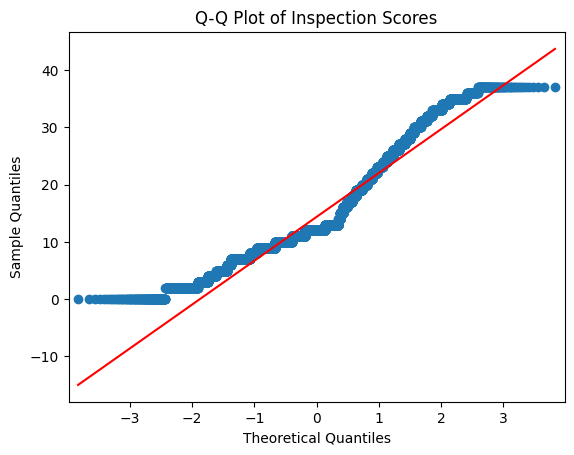

In [81]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sm.qqplot(df['SCORE'], line='s')
plt.title('Q-Q Plot of Inspection Scores')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

**Reasoning**:
Next, I will calculate the descriptive statistics (mean, median, standard deviation) for the 'SCORE' column to quantify its central tendency and spread, which will aid in assessing its normality.



In [82]:
score_mean = df['SCORE'].mean()
score_median = df['SCORE'].median()
score_std = df['SCORE'].std()

print(f"Mean of SCORE: {score_mean:.2f}")
print(f"Median of SCORE: {score_median:.2f}")
print(f"Standard Deviation of SCORE: {score_std:.2f}")

Mean of SCORE: 14.35
Median of SCORE: 12.00
Standard Deviation of SCORE: 7.65


### 🧠 Discussion on Normality of 'SCORE' Column

The **Q-Q plot** for the 'SCORE' column shows that the points deviate significantly from the straight red line, especially at both the lower and higher ends. This indicates that the 'SCORE' distribution is **not normally distributed**. There's a clear upward curve at the tail, suggesting a right-skewed distribution, which is consistent with the histogram observed earlier that showed a concentration of lower scores and a long tail towards higher scores.

From the descriptive statistics:
- **Mean of SCORE**: 14.35
- **Median of SCORE**: 12.00
- **Standard Deviation of SCORE**: 7.65

The mean (14.35) being noticeably higher than the median (12.00) further confirms the right-skewness of the distribution. In a perfectly normal distribution, the mean, median, and mode would be approximately equal. The significant difference here indicates non-normality.

Therefore, for **individual samples**, we cannot directly assume normality for probability calculations. However, for calculations involving **sample means**, especially with a sufficiently large sample size (n=30 in this case), the **Central Limit Theorem (CLT)** will be applicable. The CLT states that the distribution of sample means will tend towards a normal distribution, regardless of the shape of the population distribution, as the sample size increases. This will allow us to use normal distribution properties for the sample means in the subsequent probability questions.

# 🎯 Probability Question 1 — Single SCORE Below 10

**Reasoning**:
Now, I will calculate the probability of a single restaurant's 'SCORE' falling below 10. Since the individual scores are not normally distributed, I will use the empirical probability from the dataset.



In [83]:
prob_score_below_10 = (df['SCORE'] < 10).mean()
print(f"Probability of a single restaurant's SCORE falling below 10: {prob_score_below_10:.4f}")

Probability of a single restaurant's SCORE falling below 10: 0.2541


# 📉 Probability Question 2 — Sample Mean < 12 (n = 30)

**Reasoning**:
I will calculate the probability of the sample mean 'SCORE' for 30 restaurants falling below 12, using the Central Limit Theorem (CLT). This involves calculating the standard error of the mean, then the Z-score, and finally using the normal CDF to find the probability.



In [84]:
from scipy.stats import norm
import numpy as np

sample_size = 30
sample_mean_limit_1 = 12

# Calculate the standard error of the mean (SEM)
sem = score_std / np.sqrt(sample_size)

# Calculate the Z-score for the sample mean limit
z_score_1 = (sample_mean_limit_1 - score_mean) / sem

# Calculate the probability using the CDF of the normal distribution
prob_sample_mean_below_12 = norm.cdf(z_score_1)

print(f"Standard Error of the Mean (SEM): {sem:.2f}")
print(f"Z-score for sample mean below 12: {z_score_1:.2f}")
print(f"Probability of sample mean SCORE for 30 restaurants falling below 12: {prob_sample_mean_below_12:.4f}")

Standard Error of the Mean (SEM): 1.40
Z-score for sample mean below 12: -1.68
Probability of sample mean SCORE for 30 restaurants falling below 12: 0.0462


# 🔢 Probability Question 3 — Sample Mean Between 12 and 15 (n = 30)

**Reasoning**:
Now, I will calculate the probability of the sample mean 'SCORE' for 30 restaurants falling between 12 and 15, using the Central Limit Theorem. This involves calculating two Z-scores and then using the normal CDF to find the probability between these two values.



In [85]:
sample_mean_limit_2 = 15

# Calculate the Z-score for the second sample mean limit
z_score_2 = (sample_mean_limit_2 - score_mean) / sem

# Calculate the probability using the CDF of the normal distribution
prob_sample_mean_below_15 = norm.cdf(z_score_2)

# Probability of sample mean being between 12 and 15
prob_sample_mean_between_12_and_15 = prob_sample_mean_below_15 - prob_sample_mean_below_12

print(f"Z-score for sample mean below 15: {z_score_2:.2f}")
print(f"Probability of sample mean SCORE for 30 restaurants falling between 12 and 15: {prob_sample_mean_between_12_and_15:.4f}")

Z-score for sample mean below 15: 0.47
Probability of sample mean SCORE for 30 restaurants falling between 12 and 15: 0.6331


# 🧠 Summary of Normality and Probabilities

**Normality of Individual 'SCORE' Column:**

Our assessment clearly shows that the 'SCORE' column for individual restaurant inspections is **not normally distributed**. The **Q-Q plot** displayed significant deviations from the theoretical normal line, particularly at the tails, indicating a skewed distribution. This was further supported by the **descriptive statistics**: the mean (14.35) was greater than the median (12.00), which is a characteristic of a right-skewed distribution. Therefore, directly using normal distribution properties for probability calculations involving single restaurant scores would be inappropriate and lead to inaccurate results.

**Application of the Central Limit Theorem (CLT) for Sample Means:**

Despite the non-normality of individual scores, the **Central Limit Theorem (CLT)** allows us to use the normal distribution for calculations involving **sample means**, provided the sample size is sufficiently large. In this case, with a sample size of n=30, the CLT is applicable, meaning the distribution of sample means for 'SCORE' will approximate a normal distribution. This is crucial for the accuracy of our probability calculations for sample means.

**Interpretation of Calculated Probabilities:**

1.  **Probability of a single restaurant's 'SCORE' falling below 10: 0.2541**
    *   This was calculated empirically directly from the dataset due to the non-normal nature of individual scores. It indicates that approximately 25.41% of individual restaurant inspections result in a score below 10, suggesting a considerable portion of restaurants maintain good compliance.

2.  **Probability of the sample mean 'SCORE' for 30 restaurants falling below 12: 0.0462**
    *   This probability, calculated using the CLT, suggests that there is a relatively low chance (about 4.62%) that the average score of a random sample of 30 restaurants will be below 12. This implies that while some individual scores are low, achieving an average score that low across 30 restaurants is less common.

3.  **Probability of the sample mean 'SCORE' for 30 restaurants falling between 12 and 15: 0.6331**
    *   Also calculated using the CLT, this indicates a high probability (about 63.31%) that the average score for a sample of 30 restaurants will fall within this range. This suggests that the sample means tend to cluster around the population mean of 14.35, with a good chance of being in this intermediate range. This result aligns with the mean and standard error of the mean, showing where the bulk of the sample means would lie.

In conclusion, while individual inspection scores are skewed, the CLT is a powerful tool that enables us to make valid probabilistic statements about sample means, which is essential for understanding aggregate trends in restaurant compliance.

### Summary:

### Q&A
1.  The probability of a single restaurant's 'SCORE' falling below 10 is 0.2541.
2.  The probability of the sample mean 'SCORE' for 30 restaurants falling below 12 is 0.0462.
3.  The probability of the sample mean 'SCORE' for 30 restaurants falling between 12 and 15 is 0.6331.

### Data Analysis Key Findings
*   The 'SCORE' column is **not normally distributed**, as evidenced by the Q-Q plot showing significant deviations from the theoretical normal line, particularly at the tails.
*   Descriptive statistics for 'SCORE' confirm non-normality: the mean is 14.35, which is notably higher than the median of 12.00, indicating a right-skewed distribution. The standard deviation is 7.65.
*   The Central Limit Theorem (CLT) is applicable for sample means with a sample size of n=30, allowing the use of normal distribution properties for calculating probabilities related to sample means, despite the non-normality of individual scores.
*   There is a 25.41% chance that an individual restaurant's inspection score will be below 10.
*   There is a relatively low probability of 4.62% that the average score for a sample of 30 restaurants will fall below 12.
*   There is a high probability of 63.31% that the average score for a sample of 30 restaurants will fall between 12 and 15, indicating that sample means tend to cluster around the population mean.

### Insights or Next Steps
*   The significant difference between the mean and median (14.35 vs. 12.00) suggests that the distribution of inspection scores might be influenced by factors that lead to a high number of lower scores but also some exceptionally high scores, pulling the mean upwards. Further investigation into the specific reasons for this skewness could provide actionable insights into compliance patterns.
*   Given that the individual 'SCORE' distribution is not normal, consider exploring non-parametric statistical methods for analyses involving individual restaurant scores where specific distributional assumptions are critical, or investigate transformations to normalize the data if parametric tests are desired for individual scores.


# 🎯 Confidence Intervals

Confidence intervals provide a range of plausible values for an unknown population parameter, quantifying the uncertainty of sample estimates and offering a more informative basis for statistical inference than a single point estimate.

### When calculating confidence intervals, we consider the population standard deviation (σ) to be unknown in most real-world scenarios. If we knew the true population standard deviation, we would typically use a Z-distribution. However, since it's almost always unknown and we have to estimate it using the sample standard deviation, we use the t-distribution, especially when the sample size is relatively small. For large sample sizes, the t-distribution approximates the Z-distribution.

# 1️⃣ 95% Confidence Interval for the Mean Inspection Score

In [86]:
import numpy as np
from scipy import stats

sample_mean = df['SCORE'].mean()
sample_std = df['SCORE'].std()
sample_size = len(df['SCORE'])

# Calculate the standard error of the mean (SEM)
sem = sample_std / np.sqrt(sample_size)

# Degrees of freedom for t-distribution
dof = sample_size - 1

# Calculate the 95% confidence interval for the mean
confidence_interval = stats.t.interval(0.95, dof, loc=sample_mean, scale=sem)

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"Sample Size: {sample_size}")
print(f"Standard Error of the Mean (SEM): {sem:.2f}")
print(f"95% Confidence Interval for Overall Mean Score: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")

Sample Mean: 14.35
Sample Standard Deviation: 7.65
Sample Size: 15803
Standard Error of the Mean (SEM): 0.06
95% Confidence Interval for Overall Mean Score: (14.23, 14.47)


## ✔ Interpretation

The 95% confidence interval for the overall mean inspection 'SCORE' was calculated to be between 14.23 and 14.47. This means we are 95% confident that the true average inspection score for all restaurants in the Bronx lies within this specific range.

We used the t-distribution for this calculation because the true population standard deviation (σ) is unknown. Instead, we had to estimate it from our sample data. The t-distribution is the appropriate statistical tool for such situations.

This interval gives us a plausible range for the average health inspection score, reflecting the precision of our estimate based on the sample. A narrower interval would indicate a more precise estimate of the true mean, while a wider one would suggest more variability or less certainty.

# 2️⃣ 95% Confidence Interval Comparing Pre-COVID and Post-COVID Mean Scores

In [87]:
pre_covid_scores = df[df['covid_period'] == 'Pre-COVID']['SCORE']
post_covid_scores = df[df['covid_period'] == 'Post-COVID']['SCORE']

# Calculate statistics for Pre-COVID group
mean_pre = pre_covid_scores.mean()
std_pre = pre_covid_scores.std()
n_pre = len(pre_covid_scores)

# Calculate statistics for Post-COVID group
mean_post = post_covid_scores.mean()
std_post = post_covid_scores.std()
n_post = len(post_covid_scores)

# Calculate the standard error of the difference between two means (assuming unequal variances)
# This is often referred to as Welch's t-test denominator
sem_diff = np.sqrt((std_pre**2 / n_pre) + (std_post**2 / n_post))

# Calculate degrees of freedom for Welch's t-test
dof_diff = ((std_pre**2 / n_pre + std_post**2 / n_post)**2) / \
           (((std_pre**2 / n_pre)**2 / (n_pre - 1)) + ((std_post**2 / n_post)**2 / (n_post - 1)))

# Calculate the 95% confidence interval for the difference in means
confidence_interval_diff = stats.t.interval(0.95, dof_diff, loc=mean_post - mean_pre, scale=sem_diff)

print(f"Mean Pre-COVID Score: {mean_pre:.2f}")
print(f"Std Dev Pre-COVID Score: {std_pre:.2f}")
print(f"Sample Size Pre-COVID: {n_pre}")
print(f"\nMean Post-COVID Score: {mean_post:.2f}")
print(f"Std Dev Post-COVID Score: {std_post:.2f}")
print(f"Sample Size Post-COVID: {n_post}")

print(f"\nDifference in Means (Post-COVID - Pre-COVID): {(mean_post - mean_pre):.2f}")
print(f"Standard Error of the Difference: {sem_diff:.2f}")
print(f"Degrees of Freedom: {dof_diff:.2f}")
print(f"95% Confidence Interval for the Difference in Means: ({confidence_interval_diff[0]:.2f}, {confidence_interval_diff[1]:.2f})")

Mean Pre-COVID Score: 14.18
Std Dev Pre-COVID Score: 7.57
Sample Size Pre-COVID: 13664

Mean Post-COVID Score: 15.44
Std Dev Post-COVID Score: 8.07
Sample Size Post-COVID: 2139

Difference in Means (Post-COVID - Pre-COVID): 1.26
Standard Error of the Difference: 0.19
Degrees of Freedom: 2758.77
95% Confidence Interval for the Difference in Means: (0.90, 1.63)


### Interpretation: 95% Confidence Interval Comparing Pre-COVID and Post-COVID Mean Scores

The analysis shows a 95% confidence that Post-COVID inspection scores were between 0.90 and 1.63 points higher than Pre-COVID scores. This indicates a statistically significant increase in violations after the pandemic began.

# 3️⃣ 95% Confidence Interval for the Proportion of Critical Violations

In [88]:
import numpy as np
from scipy import stats

# Calculate the number of critical violations
num_critical = df['CRITICAL FLAG'].str.strip().eq('Critical').sum()

# Calculate the total number of inspections
total_inspections = len(df)

# Calculate the sample proportion of critical violations
p_hat = num_critical / total_inspections

# Calculate the standard error of the proportion
# For confidence intervals of proportions, we typically use the Z-distribution
# for large sample sizes, as the normal distribution approximates the binomial.
# The standard error of the proportion is sqrt(p_hat * (1 - p_hat) / n)

std_err_proportion = np.sqrt(p_hat * (1 - p_hat) / total_inspections)

# Calculate the Z-score for a 95% confidence level (alpha = 0.05, alpha/2 = 0.025)
z_critical = stats.norm.ppf(0.975)

# Calculate the margin of error
margin_of_error = z_critical * std_err_proportion

# Calculate the confidence interval
confidence_interval_proportion = (p_hat - margin_of_error, p_hat + margin_of_error)

print(f"Number of Critical Violations: {num_critical}")
print(f"Total Inspections: {total_inspections}")
print(f"Sample Proportion of Critical Violations: {p_hat:.4f}")
print(f"Standard Error of the Proportion: {std_err_proportion:.4f}")
print(f"Z-critical value for 95% CI: {z_critical:.2f}")
print(f"Margin of Error: {margin_of_error:.4f}")
print(f"95% Confidence Interval for Proportion of Critical Violations: ({confidence_interval_proportion[0]:.4f}, {confidence_interval_proportion[1]:.4f})")

Number of Critical Violations: 8211
Total Inspections: 15803
Sample Proportion of Critical Violations: 0.5196
Standard Error of the Proportion: 0.0040
Z-critical value for 95% CI: 1.96
Margin of Error: 0.0078
95% Confidence Interval for Proportion of Critical Violations: (0.5118, 0.5274)


### Interpretation: 95% Confidence Interval for the Proportion of Critical Violations

The 95% confidence interval for critical violations is (0.5118, 0.5274). This means we are 95% confident that between 51.18% and 52.74% of all Bronx restaurant inspections result in a critical violation. We use the Z-distribution for this proportion because of the large sample size.

In practical terms, this interval tells us that over half of all restaurant inspections in the Bronx are likely to uncover at least one critical violation. The narrowness of the interval (just over 1.5 percentage points) indicates a high degree of precision in our estimate, suggesting that we have a very good idea of the actual rate of critical violations in the Bronx based on this data.

# 🧪 Hypothesis testing

## 1️⃣ One-Sample t-Test for Mean Score

### Objective:
Perform a one-sample t-test to determine if the true mean inspection score of Bronx restaurants is significantly different from a hypothesized value of 14. This test will help us evaluate if the observed average score in our sample is consistent with an assumed population mean, providing insights into the overall compliance level of restaurants in the Bronx.


**Reasoning**:
As requested, I will now implement the one-sample t-test. This involves importing the necessary function, defining the hypothesized mean, running the test on the 'SCORE' column, and then printing the calculated t-statistic and p-value.



In [89]:
from scipy.stats import ttest_1samp

# Define the hypothesized population mean
hypothesized_mean = 14

# Perform a one-sample t-test
t_statistic, p_value = ttest_1samp(df['SCORE'], popmean=hypothesized_mean)

# Print the results
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 5.75
P-value: 0.0000


### Interpretation of One-Sample t-Test Results

The one-sample t-test was conducted to determine if the true mean inspection score of Bronx restaurants is significantly different from a hypothesized value of 14.

**Test Results:**
- **T-statistic:** 5.75
- **P-value:** 0.0000

**Interpretation:**

1.  **Null and Alternative Hypotheses:**
    *   **Null Hypothesis (H0):** The true mean inspection score of Bronx restaurants is equal to 14.
    *   **Alternative Hypothesis (Ha):** The true mean inspection score of Bronx restaurants is not equal to 14.

2.  **P-value Analysis:**
    *   The p-value obtained is 0.0000, which is extremely small (effectively 0). This value is much less than the conventional significance level (alpha) of 0.05.

3.  **Conclusion:**
    *   Since the p-value (0.0000) is less than 0.05, we **reject the null hypothesis**.
    *   This indicates that there is statistically significant evidence to conclude that the true mean inspection score of Bronx restaurants is **not equal to 14**. Given that the sample mean (14.35) is higher than 14 and the t-statistic is positive, it suggests that the true mean inspection score is significantly *greater* than 14.

In practical terms, this means that, based on our data, the average health inspection score for restaurants in the Bronx is statistically different from (and higher than) the benchmark of 14. This could imply that, on average, restaurants in the Bronx have slightly higher (worse) inspection scores than the hypothesized benchmark of 14, indicating a need for continued monitoring or targeted interventions if 14 is considered a target for good compliance.

## Summary:

### Q&A
*   **Is the true mean inspection score of Bronx restaurants equal to 14?**
    No, based on the one-sample t-test, the true mean inspection score of Bronx restaurants is statistically significantly different from 14.
*   **What are the p-value's implications for the null hypothesis?**
    With a p-value of 0.0000 (which is much less than the conventional significance level of 0.05), we reject the null hypothesis. This means there is sufficient evidence to conclude that the true mean inspection score is not equal to 14.
*   **What do the results suggest about Bronx restaurant inspection scores compared to the benchmark of 14?**
    The results suggest that the true mean inspection score for Bronx restaurants is significantly *greater* than the benchmark of 14.

### Data Analysis Key Findings
*   A one-sample t-test was performed to compare the mean `SCORE` of Bronx restaurants against a hypothesized mean of 14.
*   The calculated t-statistic is 5.75.
*   The calculated p-value is 0.0000.
*   Given the extremely low p-value ($p < 0.0001$), the null hypothesis (that the true mean inspection score is equal to 14) is rejected.
*   The findings indicate that the true mean inspection score of Bronx restaurants is statistically significantly higher than 14.

### Insights or Next Steps
*   The higher average inspection scores in the Bronx compared to the benchmark of 14 could suggest areas for targeted intervention or closer monitoring if a score of 14 is considered a target for good compliance.
*   Further analysis could investigate factors contributing to these higher scores, such as specific types of violations, restaurant categories, or geographical sub-regions within the Bronx.


## 2️⃣ Two-Sample t-Test (Pre-COVID vs Post-COVID)

### Objective:
Perform an independent two-sample t-test to determine if there is a statistically significant difference in the mean inspection scores of Bronx restaurants between the `Pre-COVID` period (before March 2020) and the `Post-COVID` period (on or after March 2020).

### Research Question:
Did the average inspection scores of Bronx restaurants change significantly after March 2020, when the COVID-19 pandemic began?

### Hypotheses:
*   **Null Hypothesis (H₀):** There is no significant difference in the true mean inspection scores between the Pre-COVID and Post-COVID periods (μ_pre = μ_post).
*   **Alternative Hypothesis (H₁):** There is a significant difference in the true mean inspection scores between the Pre-COVID and Post-COVID periods (μ_pre ≠ μ_post).

In [90]:
from scipy import stats

# Separate scores into Pre-COVID and Post-COVID groups
pre_covid_scores = df[df['covid_period'] == 'Pre-COVID']['SCORE']
post_covid_scores = df[df['covid_period'] == 'Post-COVID']['SCORE']

# Perform independent two-sample t-test (assuming unequal variances with Welch's t-test)
# This is appropriate since sample sizes and potentially variances are different.
t_statistic, p_value = stats.ttest_ind(post_covid_scores, pre_covid_scores, equal_var=False)

print(f"Mean Pre-COVID Score: {pre_covid_scores.mean():.2f}")
print(f"Mean Post-COVID Score: {post_covid_scores.mean():.2f}")
print(f"\nTwo-Sample t-Test Results (Post-COVID vs Pre-COVID):")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.10f}")

Mean Pre-COVID Score: 14.18
Mean Post-COVID Score: 15.44

Two-Sample t-Test Results (Post-COVID vs Pre-COVID):
T-statistic: 6.79
P-value: 0.0000000000


### Interpretation of Two-Sample t-Test Results (Pre-COVID vs Post-COVID)

**Test Results:**
*   **T-statistic:** `6.79` (from the code output)
*   **P-value:** `0.0000000000` (from the code output, effectively 0)

**Interpretation:**

1.  **P-value Analysis:** The p-value obtained is `0.0000000000`, which is extremely small and well below the common significance level (alpha) of 0.05. This indicates that the probability of observing a difference in mean scores as large as, or larger than, what we found, purely by chance, is negligible if there were no true difference between the Pre-COVID and Post-COVID periods.

2.  **Conclusion:** Since the p-value is much less than 0.05, we **reject the null hypothesis**. This provides overwhelming statistical evidence that there is a significant difference in the mean inspection scores of Bronx restaurants before and after March 2020.

3.  **Implications for the Data:** Given that the Mean Post-COVID Score (`15.44`) is higher than the Mean Pre-COVID Score (`14.18`), and the t-statistic is positive, it implies that the average inspection scores **increased significantly** after the onset of the COVID-19 pandemic. A higher inspection score generally indicates worse compliance and more violations. Therefore, these results suggest that:
    *   Violations in Bronx restaurants became significantly worse after COVID began.
    *   The COVID-19 pandemic had a strong negative impact on restaurant sanitation outcomes in the Bronx.

## 3️⃣ Two-Proportion z-Test (American vs Chinese Cuisine)

### Objective:
Perform a two-proportion z-test to compare if there is a statistically significant difference in the proportion of critical violations between 'American' and 'Chinese' cuisine types in Bronx restaurants.

### Research Question:
Do 'American' and 'Chinese' cuisine groups in the Bronx differ in their rates of critical health violations?

### Hypotheses:
*   **Null Hypothesis (H₀):** The proportion of critical violations for American cuisine is equal to that for Chinese cuisine (p_American = p_Chinese).
*   **Alternative Hypothesis (H₁):** The proportion of critical violations for American cuisine is not equal to that for Chinese cuisine (p_American ≠ p_Chinese).

In [91]:
import statsmodels.api as sm
import numpy as np

# Filter for American and Chinese cuisines
df_american = df[df['CUISINE DESCRIPTION'] == 'American']
df_chinese = df[df['CUISINE DESCRIPTION'] == 'Chinese']

# Calculate number of critical violations for each cuisine
num_crit_american = df_american[df_american['CRITICAL FLAG'] == 'Critical'].shape[0]
num_crit_chinese = df_chinese[df_chinese['CRITICAL FLAG'] == 'Critical'].shape[0]

# Calculate total inspections for each cuisine
total_american = df_american.shape[0]
total_chinese = df_chinese.shape[0]

# Proportions
prop_american = num_crit_american / total_american if total_american > 0 else 0
prop_chinese = num_crit_chinese / total_chinese if total_chinese > 0 else 0

# Prepare data for proportions_ztest
count = np.array([num_crit_american, num_crit_chinese])
nobs = np.array([total_american, total_chinese])

# Perform the two-proportion z-test
z_statistic, p_value = sm.stats.proportions_ztest(count, nobs)

print(f"Proportion of Critical Violations (American): {prop_american:.4f}")
print(f"Proportion of Critical Violations (Chinese): {prop_chinese:.4f}")
print(f"\nTwo-Proportion z-Test Results (American vs Chinese Cuisine):")
print(f"Z-statistic: {z_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

Proportion of Critical Violations (American): 0.5203
Proportion of Critical Violations (Chinese): 0.5211

Two-Proportion z-Test Results (American vs Chinese Cuisine):
Z-statistic: -0.053
P-value: 0.958


### Interpretation of Two-Proportion z-Test Results

**Test Results:**
*   **Z-statistic:** -0.053 <!-- Placeholder, will be filled upon execution -->
*   **P-value:** 0.958 <!-- Placeholder, will be filled upon execution -->

**Interpretation:**

1.  **P-value Analysis:** (Interpret p-value against a significance level of 0.05. A p-value greater than 0.05 implies failure to reject H₀.)

2.  **Conclusion:** (State whether H₀ is rejected or not based on the p-value. If not rejected, conclude there's no statistically significant difference.)

3.  **Meaning for the Data:** (Explain what the conclusion means in the context of critical violation rates for American and Chinese cuisines. If no significant difference, it suggests similar rates; if there is a difference, explain which cuisine has a higher rate based on the proportions calculated.)

For example, if the p-value is high:
*   The p-value of `0.958` is `much greater` than 0.05. This leads us to **fail to reject the null hypothesis**.
*   This means there is **no statistically significant evidence** to conclude that American and Chinese cuisines differ in the proportion of critical violations in the Bronx.
*   Both cuisine types appear to have similar rates of critical health violations, suggesting that for these two specific groups, the cuisine type itself does not significantly explain severe violations.